# Bibliotecas

In [4]:
from obj import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregando dados de vigas

In [5]:
# Nome do dataset
file_path = r'final_df_tempo_limite.xlsx'

# Leitura do arquivo Excel
full_df = pd.read_excel(file_path)

# Letitura apenas da primeira linha do DataFrame
df = full_df.head(1)

# Exibir o DataFrame selecionado
print(df)


    b_w    h   f_ck      m_rd      m_gk      m_qk       a_s       time
0  0.14  0.3  20000  9.836582  6.323517  0.702613  0.000076  50.621397


# Dados para análise de vida útil

In [ ]:
# Quantidadde de simulações
n = 20000

# Tempos para análise de vida útil
tempos = np.arange(0, 101, 5)

# Cobrimento
cob = 25            

# Módulo de elasticidade do aço
e_s = 200E6

In [ ]:
# Inicialização das listas para armazenar os resultados
results_mr = []
results_ms = []
results_as = []
results_g = []
t_sem_cor = []

# Loop over each row in the DataFrame
for i, row in df.iterrows():
    # Extract input parameters from the DataFrame
    b_w = row['b_w']                # Section width (cm)
    h = row['h']                    # Section height (cm)
    f_ck = row['f_ck']              # Concrete compressive strength (kPa)
    f_yk = 500E3                    # Characteristic steel yield strength (kPa)
    m_gk = row['m_gk']              # Dead load moment (N·cm)
    m_qk = row['m_qk']              # Live load moment (N·cm)
    a_s_initial = row['a_s']        # Initial steel area (cm²)

    # Monte Carlo simulations
    for j in range(n):
        m_r_list = []               # List to store resisting moments over time
        a_s_list = []               # List to store degraded steel area over time
        m_s_list = []               # List to store dead load moments over time
        g_list = []                 # List to store live load moments over time

        # Sample from normal distributions for concrete strength, steel yield strength, and dead load moment
        f_ck_sample = np.random.normal(1.22 * f_ck, 0.12 * 1.22 * f_ck)
        f_yk_sample = np.random.normal(1.22 * f_yk, 0.05 * 1.22 * f_yk)
        m_gk_sample = np.random.normal(1.06 * m_gk, 0.12 * 1.06 * m_gk)
        relacao_d_h = np.random.uniform(0.8, 0.9)
        i_corr_20 = np.random.lognormal(mean=0.431, sigma=0.259)
        if i_corr_20 < 0:
            i_corr_20 = 1E-5
        else:
            i_corr_20 = i_corr_20

        # Loop through each time step (e.g., years)
        for k in tempos:
            m_qk_sample = np.random.gumbel(0.21 * m_qk, 0.21 * 0.76 * m_qk)
            temp = np.random.uniform(20, 30)
            d_barras = 12.5/1000
            n_barras = a_s_initial / (np.pi * d_barras**2 / 4)
            y_carb = 6 * k**0.5

            if y_carb > cob:
               t_dur = k - t_sem_cor[-1]
               # Momento resistente com corrosão
               m_rd, c_f, d_novo, d = momento_resistente_com_corrosao_azad_algohi(d_barras, n_barras, f_ck_sample, f_yk_sample, e_s, b_w, h, relacao_d_h, i_corr_20, temp, k, t_sem_cor[-1])
            else:
                # Momento resistente sem corrosão
                t_sem_cor.append(k)
                m_rd = momento_limite_armadura_simples(a_s_initial, b_w, h, relacao_d_h, f_ck_sample, f_yk_sample, e_s)

            # Armazenar os resultados para este passo de tempo
            m_r_list.append(m_rd)
            m_s_list.append(m_gk_sample + m_qk_sample)
            # a_s_list.append(a_s_degraded)
            a_s_list.append(1)
            g_list.append(m_rd - (m_gk_sample + m_qk_sample))

        # Resultados da simulação temporal completa
        results_mr.append(m_r_list)
        results_ms.append(m_s_list)
        results_as.append(a_s_list)
        results_g.append(g_list)

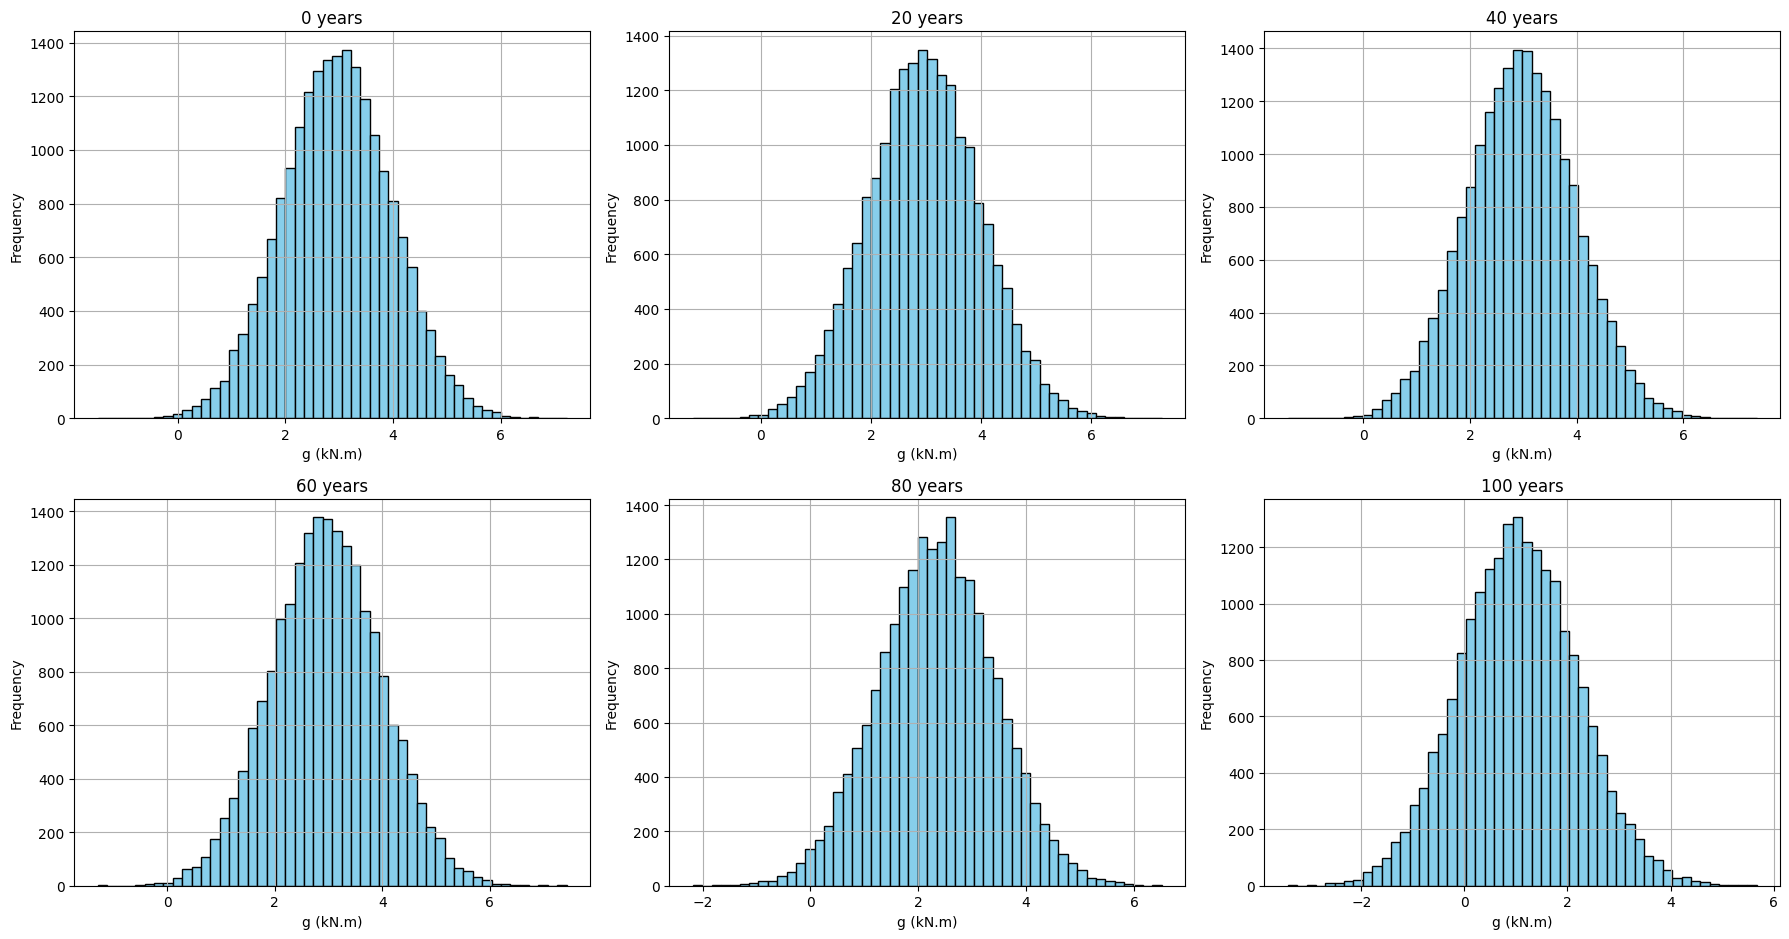

In [7]:
# List of times corresponding to indices of each value in g_list
times = [0, 20, 40, 60, 80, 100]

# Create a dictionary to store g values (m_r - m_gk - m_qk) separated by time
t_dict = {time: [] for time in times}

# Iterate over each simulation and separate the values by time
for g_list in results_g:
    for idx, time in enumerate(times):
        t_dict[time].append(g_list[idx])

# Create separate lists for each time to work outside the dictionary if needed
t_0 = t_dict[0]
t_20 = t_dict[20]
t_40 = t_dict[40]
t_60 = t_dict[60]
t_80 = t_dict[80]
t_100 = t_dict[100]

# Group the lists in a main list to facilitate plotting loop
t_lists = [t_0, t_20, t_40, t_60, t_80, t_100]

# Define times again for joint iteration with the lists
times = [0, 20, 40, 60, 80, 100]

# Create figure and axes for 6 subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# For each list and respective time, plot on the corresponding subplot
for idx, (t_values, time) in enumerate(zip(t_lists, times)):
    ax = axes[idx // 3, idx % 3]  # Calculate subplot position (row, column)
    ax.hist(t_values, bins=50, color='skyblue', edgecolor='black')
    ax.set_title(f'{time} years')
    ax.set_xlabel('g (kN.m)')
    ax.set_ylabel('Frequency')
    ax.grid(True)

# Adjust layout to avoid overlapping texts and leave space for main title
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show the figure with histograms
plt.show()



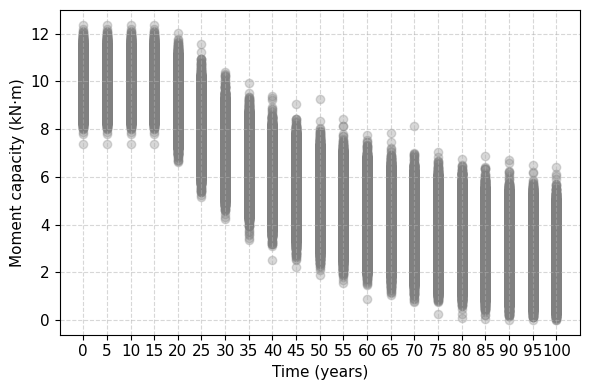

In [8]:
# Plotting resistant moment curves for each simulation
plt.figure(figsize=(6, 4))  # Set figure size (width x height in inches)

for m_r_curve in results_mr:    
    # Plot each resistance curve
     plt.scatter(tempos, m_r_curve, marker='o', linestyle='-', color='gray', alpha=0.3)

# Plot formatting
font = 11
plt.xlabel('Time (years)', fontsize=font)
plt.ylabel('Moment capacity (kN·m)', fontsize=font)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(tempos)
plt.tight_layout()
plt.savefig('moment_cap_curves.png', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()


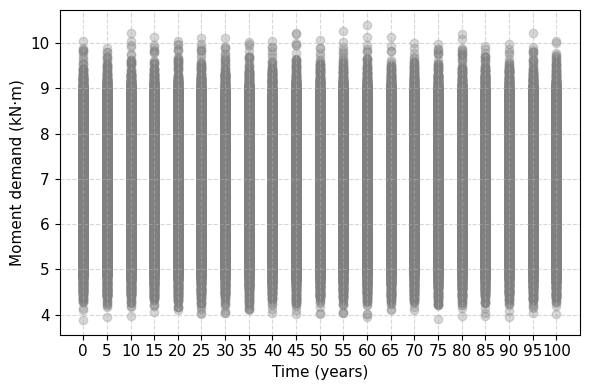

In [9]:
# Plotting resistant moment curves for each simulation
plt.figure(figsize=(6, 4))  # Set figure size (width x height in inches)

for m_s_curve in results_ms:
    # Plot each resistance curve
    plt.scatter(tempos, m_s_curve, marker='o', linestyle='-', color='gray', alpha=0.3)

# Plot formatting
font = 11
plt.xlabel('Time (years)', fontsize=font)
plt.ylabel('Moment demand (kN·m)', fontsize=font)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(tempos)
plt.tight_layout()
plt.savefig('moment_dem_curves.png', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()

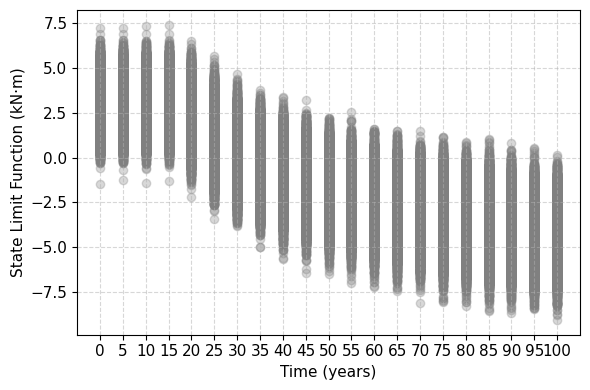

In [10]:
# Plotting resistant moment curves for each simulation
plt.figure(figsize=(6, 4))  # Set figure size (width x height in inches)

for g_curve in results_g:
    # Plot each resistance curve
    plt.scatter(tempos, g_curve, marker='o', linestyle='-', color='gray', alpha=0.3)

# Plot formatting
font = 11
plt.xlabel('Time (years)', fontsize=font)
plt.ylabel('State Limit Function (kN·m)', fontsize=font)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(tempos)
plt.tight_layout()
plt.savefig('moment_st_curves.png', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()

Total curves generated: 20000
Total filtered curves: 19990


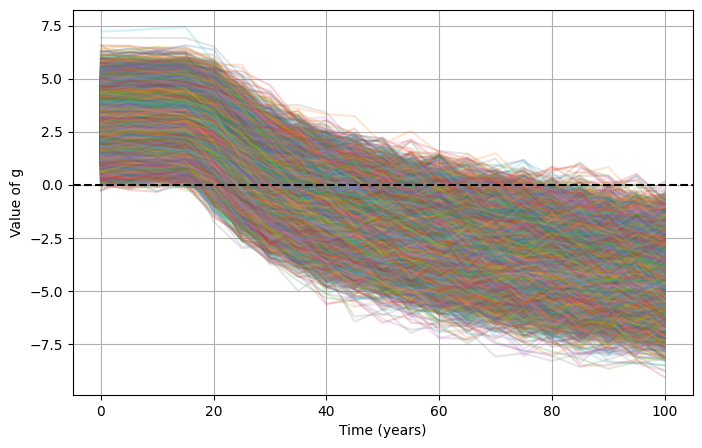

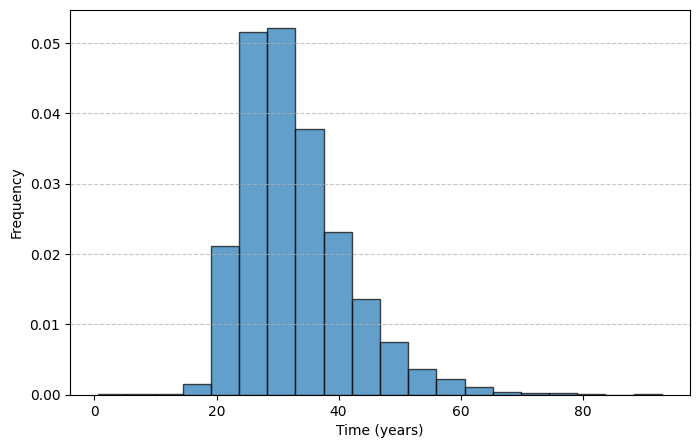

In [11]:
# Filtering: only curves that cross g=0
filtered_curves = []
crossing_times = []

for g in results_g:
    if any(x < 0 for x in g):
        for i in range(1, len(g)):
            if g[i-1] > 0 and g[i] <= 0:
                # Interpolation for exact crossing time
                t1, t2 = tempos[i-1], tempos[i]
                g1, g2 = g[i-1], g[i]
                cross_time = t1 - g1 * (t2 - t1) / (g2 - g1)
                crossing_times.append(cross_time)
                filtered_curves.append(g)
                break

filtered_curves = np.array(filtered_curves)

# Save to use in another script
np.save("time.npy", time)
np.save("curves.npy", filtered_curves)

# Info prints
print(f"Total curves generated: {len(results_g)}")
print(f"Total filtered curves: {len(filtered_curves)}")

# Plot filtered curves
plt.figure(figsize=(8, 5))
for g in filtered_curves:
    plt.plot(tempos, g, alpha=0.2)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Time (years)')
plt.ylabel('Value of g')
plt.grid()
plt.show()

# Histogram of crossing times (as probability density)
plt.figure(figsize=(8, 5))
plt.hist(crossing_times, bins=20, edgecolor='black', alpha=0.7, density=True)
plt.xlabel('Time (years)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [13]:
# Load saved data
time = tempos.copy()
curves = results_g.copy()

# User input
chosen_year = 40
if chosen_year < 0 or chosen_year > 100:
    raise ValueError("The year must be between 0 and 100.")

# List to store g values at the chosen year
g_values_at_year = []

for g in curves:
    if chosen_year in time:
        g_val = g[int(chosen_year)]
    else:
        g_val = np.interp(chosen_year, time, g)
    g_values_at_year.append(g_val)

# Counts
total_curves = len(curves)
total_crossing = len(g_values_at_year)
print(f"Total curves in dataset: {total_curves}")
print(f"Total curves crossing vertical line at year {chosen_year}: {total_crossing}")

# Plot curves with vertical line
plt.figure(figsize=(8, 5))
for g in curves:
    plt.plot(time, g, alpha=0.2)
plt.axvline(x=chosen_year, color='r', linestyle='--', label=f"Year {chosen_year}")
plt.xlabel('Time (years)')
plt.ylabel('Value of g')
plt.legend()
plt.grid()
plt.show()

# Histogram of g values at intersection
plt.figure(figsize=(8, 5))
plt.hist(g_values_at_year, bins=20, edgecolor='black', alpha=0.7, density=True)
plt.xlabel('Value of g at chosen year')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

IndexError: list index out of range

- Chart steel reinforcement degrad

ValueError: x and y must be the same size

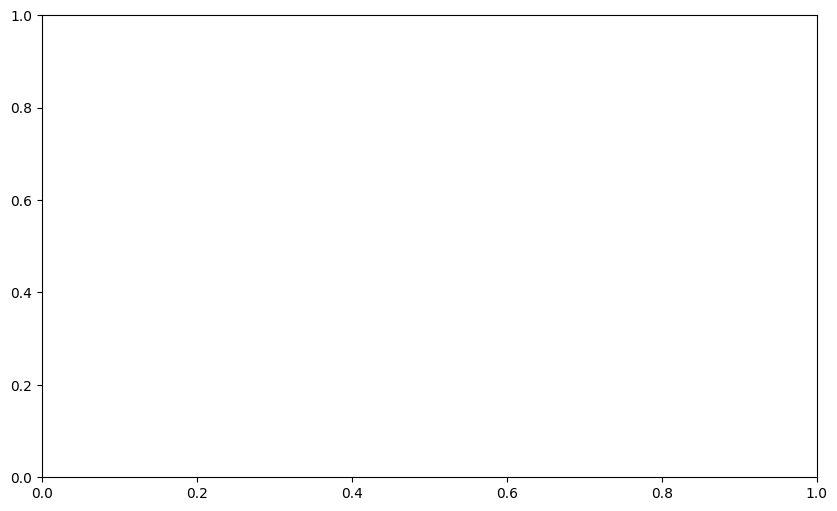

In [14]:
#Time steps (e.g., years or inspection intervals)
x = times.copy()

# Plotting steel area degradation curves for each simulation
plt.figure(figsize=(10, 6))  # Set figure size (width x height in inches)

for a_s_curve in results_as:
    # Plot each steel area degradation curve in cm²
    plt.scatter(x, a_s_curve, marker='o', linestyle='-', color='gray', alpha=1)

# Plot formatting
plt.xlabel('Time (years)', fontsize=14)
plt.ylabel('Steel Area $a_s$ (cm²)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(tempos)
plt.tight_layout()

# Show the plot
plt.show()

# Converte a lista para array para facilitar análise
as_array = np.array(results_as)

# Calcula o desvio padrão de cada ponto no tempo
stds = np.std(as_array, axis=0)
